Counterexample found (single sample):
 trial = 1, m = 20, sigma = 3.0, lr = 0.15
 raw shrinkage c_raw = 0.157728, positive c_pos = 0.157728
 MSE (noisy grad) = 180.961324
 MSE (JS denoised) = 40.751856
 loss after step (noisy grad) = 20.364416
 loss after step (JS grad)    = 21.805137

Per-component comparison (index: G, JS_est, true_grad, err_MLE, err_JS):
 0: -0.3343, -0.0527,  2.3000,  6.9397,  5.5353
 1:  1.5494,  0.2444,  2.0187,  0.2202,  3.1481
 2:  2.4824,  0.3915,  1.7127,  0.5925,  1.7455
 3: -1.5271, -0.2409,  1.4393,  8.7992,  2.8228
 4:  0.2220,  0.0350,  1.2385,  1.0332,  1.4484
 5:  0.4183,  0.0660,  1.1268,  0.5020,  1.1254
 6: -0.8166, -0.1288,  1.0963,  3.6594,  1.5010
 7: -2.4423, -0.3852,  1.1205, 12.6938,  2.2673
 8: -3.0994, -0.4889,  1.1643, 18.1787,  2.7329
 9:  0.7351,  0.1159,  1.1956,  0.2120,  1.1657
10:  0.3884,  0.0613,  1.1956,  0.6515,  1.2867
11:  7.8584,  1.2395,  1.1643, 44.8110,  0.0057
12: -6.1838, -0.9754,  1.1205, 53.3528,  4.3927
13:  1.4345,  0.

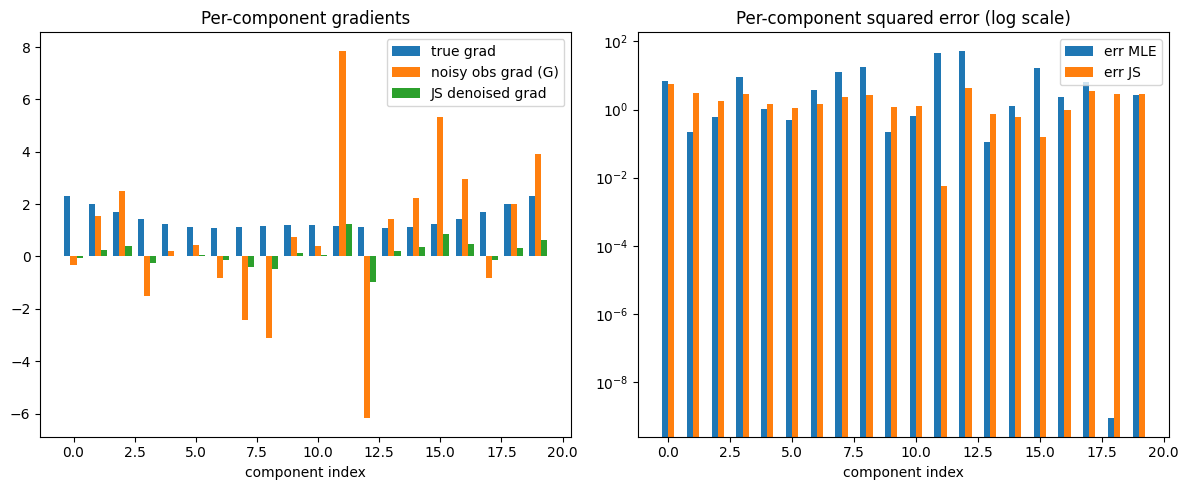

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def james_stein_positive(vec, sigma2):
    """Return (c_pos * vec, c_pos, c_raw)."""
    m = vec.size
    norm2 = np.sum(vec**2)
    if norm2 == 0:
        c_raw = -np.inf
    else:
        c_raw = 1.0 - (m - 2) * sigma2 / norm2
    c_pos = max(c_raw, 0.0)
    return c_pos * vec, c_pos, c_raw

# Quadratic objective: f(x) = 0.5 * ||x - theta||^2  -> grad = x - theta
def loss(x, theta):
    return 0.5 * np.sum((x - theta)**2)

def true_grad(x, theta):
    return x - theta

def find_counterexample(
    m=12,
    theta=None,
    x_init=None,
    sigma=3.0,
    lr=0.15,
    trials=200000,
    seed=0,
    target_c_max=0.2
):
    """
    Search for a sample where:
      - JS denoised grad has smaller squared error than the noisy grad (mse_js < mse_mle)
      - but one GD step using JS increases the loss relative to one step using noisy grad (loss_js > loss_mle)
    Returns dict or None.
    """
    rng = np.random.RandomState(seed)

    # default theta: non-constant vector (e.g., sinusoidal around 0)
    if theta is None:
        theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))  # varied true minimizer

    # default x_init: non-constant starting point (not all 2s)
    if x_init is None:
        x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))  # varied starting point

    g = true_grad(x_init, theta)
    sigma2 = sigma**2

    for t in range(trials):
        noise = rng.normal(0.0, sigma, size=m)
        G = g + noise  # observed noisy gradient

        JS_est, c_pos, c_raw = james_stein_positive(G, sigma2)

        mse_mle = np.sum((G - g)**2)
        mse_js  = np.sum((JS_est - g)**2)

        # one gradient descent step with each gradient
        x_mle = x_init - lr * G
        x_js  = x_init - lr * JS_est
        loss_mle = loss(x_mle, theta)
        loss_js  = loss(x_js, theta)

        # require JS shrinkage to be small but positive (close to 0)
        if (0 < c_pos <= target_c_max) and (mse_js < mse_mle) and (loss_js > loss_mle):
            return {
                "trial": t,
                "m": m,
                "theta": theta,
                "x_init": x_init,
                "g_true": g,
                "sigma": sigma,
                "c_raw": c_raw,
                "c_pos": c_pos,
                "G": G,
                "JS_est": JS_est,
                "mse_mle": mse_mle,
                "mse_js": mse_js,
                "loss_mle": loss_mle,
                "loss_js": loss_js,
                "lr": lr
            }
    return None

if __name__ == "__main__":
    # ---------- user-adjustable parameters ----------
    m = 20
    sigma = 3.0
    lr = 0.15
    trials = 200000
    seed = 2
    target_c_max = 0.18   # require shrinkage to be small (close to 0) but positive
    # ------------------------------------------------

    # optional: provide your own theta and x_init arrays here if desired
    res = find_counterexample(
        m=m,
        theta=None,     # None -> function will create a non-constant theta
        x_init=None,    # None -> function will create a non-constant starting point
        sigma=sigma,
        lr=lr,
        trials=trials,
        seed=seed,
        target_c_max=target_c_max
    )

    if res is None:
        print("No counterexample found. Try increasing `trials`, increase sigma, or relax target_c_max.")
    else:
        print("Counterexample found (single sample):")
        print(f" trial = {res['trial']}, m = {res['m']}, sigma = {res['sigma']}, lr = {res['lr']}")
        print(f" raw shrinkage c_raw = {res['c_raw']:.6f}, positive c_pos = {res['c_pos']:.6f}")
        print(f" MSE (noisy grad) = {res['mse_mle']:.6f}")
        print(f" MSE (JS denoised) = {res['mse_js']:.6f}")
        print(f" loss after step (noisy grad) = {res['loss_mle']:.6f}")
        print(f" loss after step (JS grad)    = {res['loss_js']:.6f}")
        print("\nPer-component comparison (index: G, JS_est, true_grad, err_MLE, err_JS):")

        for i in range(res['m']):
            g_true = res['g_true'][i]
            g_obs = res['G'][i]
            g_js = res['JS_est'][i]
            err_mle = (g_obs - g_true)**2
            err_js  = (g_js - g_true)**2
            print(f"{i:2d}: {g_obs: .4f}, {g_js: .4f}, {g_true: .4f}, {err_mle:7.4f}, {err_js:7.4f}")

        # Visualize
        idx = np.arange(res['m'])
        width = 0.25
        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.bar(idx - width, res['g_true'], width, label='true grad')
        plt.bar(idx, res['G'], width, label='noisy obs grad (G)')
        plt.bar(idx + width, res['JS_est'], width, label='JS denoised grad')
        plt.title("Per-component gradients")
        plt.xlabel("component index")
        plt.legend()

        plt.subplot(1,2,2)
        err_mle = (res['G'] - res['g_true'])**2
        err_js  = (res['JS_est'] - res['g_true'])**2
        plt.bar(idx - width/2, err_mle, width, label='err MLE')
        plt.bar(idx + width/2, err_js, width, label='err JS')
        plt.yscale('log')
        plt.title("Per-component squared error (log scale)")
        plt.xlabel("component index")
        plt.legend()

        plt.tight_layout()
        plt.show()


Tuning learning rates (this may take a few seconds)...
Best pair (by avg final JS loss over seeds): lr_noisy = 0.0015, lr_js = 0.3833, avg_final_JS_loss = 3111.543810
Tuning learning rate for true gradient trajectory...
Best lr for true gradient: lr_true = 0.1328, avg_final_loss = 1447.562427


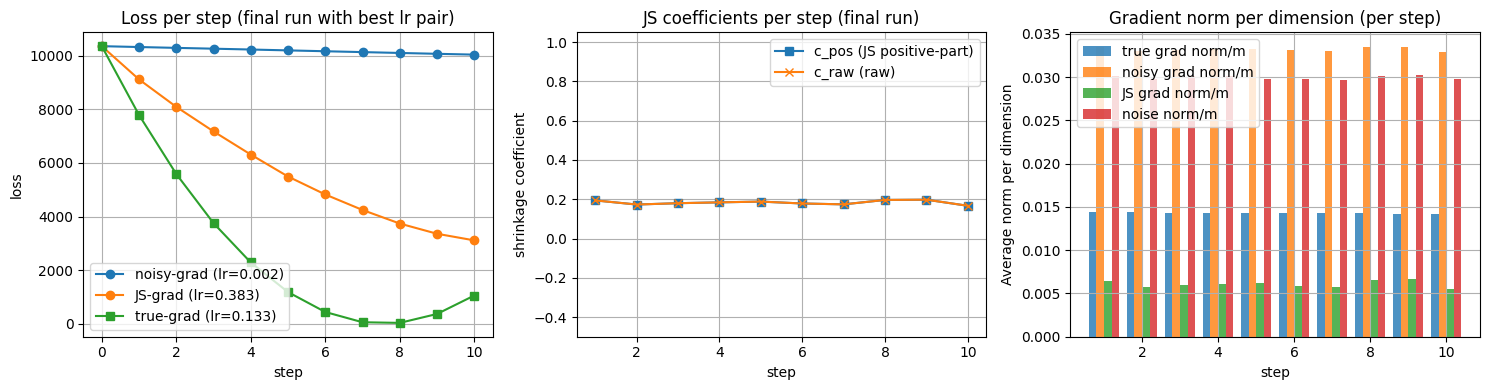


Final run summary (per-step):
 step  1: c_pos=0.194125, c_raw=0.194125, loss_noisy=10325.118016, loss_js=9116.450628, loss_true=7788.457052, norm_true/m=0.014392, norm_noisy/m=0.033415, norm_js/m=0.006487, norm_noise/m=0.030119
 step  2: c_pos=0.173091, c_raw=0.173091, loss_noisy=10293.614640, loss_js=8093.661279, loss_true=5588.353895, norm_true/m=0.014370, norm_noisy/m=0.032987, norm_js/m=0.005710, norm_noise/m=0.029754
 step  3: c_pos=0.179950, c_raw=0.179950, loss_noisy=10263.200006, loss_js=7177.011227, loss_true=3755.125326, norm_true/m=0.014348, norm_noisy/m=0.033125, norm_js/m=0.005961, norm_noise/m=0.030131
 step  4: c_pos=0.184204, c_raw=0.184204, loss_noisy=10232.259610, loss_js=6313.156277, loss_true=2287.038372, norm_true/m=0.014327, norm_noisy/m=0.033211, norm_js/m=0.006118, norm_noise/m=0.030102
 step  5: c_pos=0.188117, c_raw=0.188117, loss_noisy=10199.541970, loss_js=5493.523758, loss_true=1182.507996, norm_true/m=0.014305, norm_noisy/m=0.033291, norm_js/m=0.006263, n

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def james_stein_positive(vec, sigma2):
    m = vec.size
    norm2 = np.sum(vec**2)
    if norm2 == 0:
        c_raw = -np.inf
    else:
        c_raw = 1.0 - (m - 2) * sigma2 / norm2
    c_pos = max(c_raw, 0.0)
    return c_pos * vec, c_pos, c_raw

def loss(x, theta):
    return 0.5 * np.sum((x - theta)**2)

def true_grad(x, theta):
    return x - theta

def run_trajectory(m, theta, x_init, sigma, lr_noisy, lr_js, lr_true, steps, rng):
    """
    Run `steps` updates using the SAME observed noisy gradient G at each step:
      - update noisy trajectory with lr_noisy * G
      - update JS trajectory with lr_js * (c_pos * G)
      - update true trajectory with lr_true * g_true
    Returns arrays: losses_noisy (len steps+1), losses_js, losses_true, c_pos_list
    """
    x_noisy = x_init.copy()
    x_js = x_init.copy()
    x_true = x_init.copy()
    sigma2 = sigma**2

    losses_noisy = [loss(x_noisy, theta)]
    losses_js = [loss(x_js, theta)]
    losses_true = [loss(x_true, theta)]
    c_pos_list = []
    c_raw_list = []
    norm_true_list = []
    norm_noisy_list = []
    norm_js_list = []
    norm_noise_list = []

    for t in range(steps):
        # Observe gradient at current noisy position (consistent with earlier examples)
        g_true = true_grad(x_noisy, theta)
        
        # Update true gradient trajectory
        x_true = x_true - lr_true * g_true
        losses_true.append(loss(x_true, theta))
        
        noise = rng.normal(0.0, sigma, size=m)
        G = g_true + noise

        JS_est, c_pos, c_raw = james_stein_positive(G, sigma2)

        norm_true = np.linalg.norm(g_true) / m
        norm_noisy = np.linalg.norm(G) / m
        norm_js = np.linalg.norm(JS_est) / m
        norm_noise = np.linalg.norm(noise) / m

        # update steps (note lr_js typically larger)
        x_noisy = x_noisy - lr_noisy * G
        x_js = x_js - lr_js * JS_est

        losses_noisy.append(loss(x_noisy, theta))
        losses_js.append(loss(x_js, theta))
        c_pos_list.append(c_pos)
        c_raw_list.append(c_raw)
        norm_true_list.append(norm_true)
        norm_noisy_list.append(norm_noisy)
        norm_js_list.append(norm_js)
        norm_noise_list.append(norm_noise)

    return np.array(losses_noisy), np.array(losses_js), np.array(losses_true), np.array(c_pos_list), np.array(c_raw_list), np.array(norm_true_list), np.array(norm_noisy_list), np.array(norm_js_list), np.array(norm_noise_list)

def tune_lrs(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_noisy_grid=None,
    lr_js_grid=None
):
    """
    Independent grid search over lr_noisy and lr_js.
    For each pair, run with multiple seeds and compute avg final loss of JS trajectory.
    Choose the pair that minimizes avg final JS final loss.
    """
    if lr_noisy_grid is None:
        lr_noisy_grid = np.linspace(0.02, 0.28, 100)  # candidate lr for noisy trajectory
    if lr_js_grid is None:
        lr_js_grid = np.linspace(0.05, 0.6, 100)    # candidate lr for JS trajectory (independent)

    best = None
    results = []

    for lr_noisy in lr_noisy_grid:
        for lr_js in lr_js_grid:
            final_losses = []
            for sd in seeds:
                rng = np.random.RandomState(sd)
                # non-constant theta and x_init
                theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
                x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
                losses_noisy, losses_js, _, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, lr_noisy, lr_js, 0.1, steps, rng)
                final_losses.append(losses_js[-1])
            avg_final_js_loss = float(np.mean(final_losses))
            results.append((lr_noisy, lr_js, avg_final_js_loss))
            if (best is None) or (avg_final_js_loss < best[2]):
                best = (lr_noisy, lr_js, avg_final_js_loss)
    return best, results

def tune_lr_true(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_true_grid=None
):
    """
    Grid search for optimal learning rate for true gradient trajectory.
    """
    if lr_true_grid is None:
        lr_true_grid = np.linspace(0.01, 0.2, 100)  # candidate lr for true gradient trajectory
    
    best = None
    results = []
    
    for lr_true in lr_true_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            # Use dummy values for lr_noisy and lr_js since we only care about true trajectory
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, 0.1, 0.2, lr_true, steps, rng)
            final_losses.append(losses_true[-1])
        avg_final_true_loss = float(np.mean(final_losses))
        results.append((lr_true, avg_final_true_loss))
        if (best is None) or (avg_final_true_loss < best[1]):
            best = (lr_true, avg_final_true_loss)
    return best, results

if __name__ == "__main__":
    # -------------------- user-tunable parameters --------------------
    m = 10000
    sigma = 3.0
    steps = 10
    seeds = (999,)   # single seed for tuning
    # lr grids (you can adjust ranges)
    lr_noisy_grid = np.linspace(0.001, 0.01, 100)
    lr_js_grid = np.linspace(0.05, 0.6, 100)  # independent grid for lr_js
    # ----------------------------------------------------------------

    print("Tuning learning rates (this may take a few seconds)...")
    best, all_results = tune_lrs(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_noisy_grid=lr_noisy_grid,
        lr_js_grid=lr_js_grid
    )

    if best is None:
        print("Tuning failed.")
        raise SystemExit(1)

    best_lr_noisy, best_lr_js, best_avg_js_loss = best
    print(f"Best pair (by avg final JS loss over seeds): lr_noisy = {best_lr_noisy:.4f}, lr_js = {best_lr_js:.4f}, avg_final_JS_loss = {best_avg_js_loss:.6f}")

    print("Tuning learning rate for true gradient trajectory...")
    best_true, all_results_true = tune_lr_true(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_true_grid=np.linspace(0.01, 0.2, 100)
    )

    if best_true is None:
        print("Tuning for true gradient failed.")
        raise SystemExit(1)

    best_lr_true, best_avg_true_loss = best_true
    print(f"Best lr for true gradient: lr_true = {best_lr_true:.4f}, avg_final_loss = {best_avg_true_loss:.6f}")

    # Run a final illustrative run with the best pair using a fresh seed and display plots
    seed_final = 999
    rng = np.random.RandomState(seed_final)
    theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
    x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))

    losses_noisy, losses_js, losses_true, c_pos_list, c_raw_list, norm_true_list, norm_noisy_list, norm_js_list, norm_noise_list = run_trajectory(
        m, theta, x_init, sigma, best_lr_noisy, best_lr_js, best_lr_true, steps, rng
    )

    # Plot 1: Loss per step
    steps_range = np.arange(0, steps+1)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.plot(steps_range, losses_noisy, marker='o', label=f'noisy-grad (lr={best_lr_noisy:.3f})')
    plt.plot(steps_range, losses_js, marker='o', label=f'JS-grad (lr={best_lr_js:.3f})')
    plt.plot(steps_range, losses_true, marker='s', label=f'true-grad (lr={best_lr_true:.3f})')
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Loss per step (final run with best lr pair)")
    plt.legend()
    plt.grid(True)

    # Plot 2: JS shrinkage coefficient per step
    plt.subplot(1,3,2)
    plt.plot(np.arange(1, steps+1), c_pos_list, marker='s', label='c_pos (JS positive-part)')
    plt.plot(np.arange(1, steps+1), c_raw_list, marker='x', label='c_raw (raw)')
    plt.xlabel("step")
    plt.ylabel("shrinkage coefficient")
    plt.title("JS coefficients per step (final run)")
    plt.ylim(-0.5, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot 3: Gradient L2 norm per step
    plt.subplot(1,3,3)
    steps_range_bar = np.arange(1, steps+1)
    width = 0.2
    plt.bar(steps_range_bar - 1.5*width, norm_true_list, width, label='true grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar - 0.5*width, norm_noisy_list, width, label='noisy grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 0.5*width, norm_js_list, width, label='JS grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 1.5*width, norm_noise_list, width, label='noise norm/m', alpha=0.8)
    plt.xlabel("step")
    plt.ylabel("Average norm per dimension")
    plt.title("Gradient norm per dimension (per step)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print short summary
    print("\nFinal run summary (per-step):")
    for t in range(steps):
        print(f" step {t+1:2d}: c_pos={c_pos_list[t]:.6f}, c_raw={c_raw_list[t]:.6f}, loss_noisy={losses_noisy[t+1]:.6f}, loss_js={losses_js[t+1]:.6f}, loss_true={losses_true[t+1]:.6f}, norm_true/m={norm_true_list[t]:.6f}, norm_noisy/m={norm_noisy_list[t]:.6f}, norm_js/m={norm_js_list[t]:.6f}, norm_noise/m={norm_noise_list[t]:.6f}")

    print("\nDone.")

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def james_stein_positive(vec, sigma2):
    m = vec.size
    norm2 = np.sum(vec**2)
    if norm2 == 0:
        c_raw = -np.inf
    else:
        c_raw = 1.0 - (m - 2) * sigma2 / norm2
    c_pos = max(c_raw, 0.0)
    return c_pos * vec, c_pos, c_raw

def weighted_loss(x, theta, w):
    """Weighted quadratic loss: 0.5 * sum(w_i * (x_i - theta_i)^2)"""
    return 0.5 * np.sum(w * (x - theta)**2)

def weighted_true_grad(x, theta, w):
    """Weighted gradient: w ⊙ (x - theta)"""
    return w * (x - theta)

def run_trajectory(m, theta, x_init, sigma, lr_noisy, lr_js, lr_true, steps, rng, w):
    """
    Run `steps` updates using weighted loss function:
      - update noisy trajectory with lr_noisy * G
      - update JS trajectory with lr_js * (c_pos * G)
      - update true trajectory with lr_true * g_true
    Returns arrays: losses_noisy (len steps+1), losses_js, losses_true, c_pos_list
    """
    x_noisy = x_init.copy()
    x_js = x_init.copy()
    x_true = x_init.copy()
    sigma2 = sigma**2

    losses_noisy = [weighted_loss(x_noisy, theta, w)]
    losses_js = [weighted_loss(x_js, theta, w)]
    losses_true = [weighted_loss(x_true, theta, w)]
    c_pos_list = []
    c_raw_list = []
    norm_true_list = []
    norm_noisy_list = []
    norm_js_list = []
    norm_noise_list = []

    for t in range(steps):
        # Observe gradient at current noisy position (consistent with earlier examples)
        g_true = weighted_true_grad(x_noisy, theta, w)
        
        # Update true gradient trajectory
        x_true = x_true - lr_true * g_true
        losses_true.append(weighted_loss(x_true, theta, w))
        
        noise = rng.normal(0.0, sigma, size=m)
        G = g_true + noise

        JS_est, c_pos, c_raw = james_stein_positive(G, sigma2)

        norm_true = np.linalg.norm(g_true) / m
        norm_noisy = np.linalg.norm(G) / m
        norm_js = np.linalg.norm(JS_est) / m
        norm_noise = np.linalg.norm(noise) / m

        # update steps (note lr_js typically larger)
        x_noisy = x_noisy - lr_noisy * G
        x_js = x_js - lr_js * JS_est

        losses_noisy.append(weighted_loss(x_noisy, theta, w))
        losses_js.append(weighted_loss(x_js, theta, w))
        c_pos_list.append(c_pos)
        c_raw_list.append(c_raw)
        norm_true_list.append(norm_true)
        norm_noisy_list.append(norm_noisy)
        norm_js_list.append(norm_js)
        norm_noise_list.append(norm_noise)

    return np.array(losses_noisy), np.array(losses_js), np.array(losses_true), np.array(c_pos_list), np.array(c_raw_list), np.array(norm_true_list), np.array(norm_noisy_list), np.array(norm_js_list), np.array(norm_noise_list)

def tune_lrs(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_noisy_grid=None,
    lr_js_grid=None,
    w=None
):
    """
    Independent grid search over lr_noisy and lr_js with weighted loss.
    For each pair, run with multiple seeds and compute avg final loss of JS trajectory.
    Choose the pair that minimizes avg final JS final loss.
    """
    if lr_noisy_grid is None:
        lr_noisy_grid = np.linspace(0.0001, 0.01, 100)  # candidate lr for noisy trajectory
    if lr_js_grid is None:
        lr_js_grid = np.linspace(0.0001, 0.01, 100)    # candidate lr for JS trajectory (independent)
    if w is None:
        w = np.ones(m)

    best = None
    results = []

    for lr_noisy in lr_noisy_grid:
        for lr_js in lr_js_grid:
            final_losses = []
            for sd in seeds:
                rng = np.random.RandomState(sd)
                # non-constant theta and x_init
                theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
                x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
                losses_noisy, losses_js, _, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, lr_noisy, lr_js, 0.001, steps, rng, w)
                final_losses.append(losses_js[-1])
            avg_final_js_loss = float(np.mean(final_losses))
            results.append((lr_noisy, lr_js, avg_final_js_loss))
            if (best is None) or (avg_final_js_loss < best[2]):
                best = (lr_noisy, lr_js, avg_final_js_loss)
    return best, results

def tune_lr_true(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_true_grid=None,
    w=None
):
    """
    Grid search for optimal learning rate for true gradient trajectory with weighted loss.
    """
    if lr_true_grid is None:
        lr_true_grid = np.linspace(0.0001, 0.01, 100)  # candidate lr for true gradient trajectory
    if w is None:
        w = np.ones(m)
    
    best = None
    results = []
    
    for lr_true in lr_true_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            # Use dummy values for lr_noisy and lr_js since we only care about true trajectory
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, 0.001, 0.001, lr_true, steps, rng, w)
            final_losses.append(losses_true[-1])
        avg_final_true_loss = float(np.mean(final_losses))
        results.append((lr_true, avg_final_true_loss))
        if (best is None) or (avg_final_true_loss < best[1]):
            best = (lr_true, avg_final_true_loss)
    return best, results

if __name__ == "__main__":
    # -------------------- user-tunable parameters --------------------
    m = 10000
    sigma = 3.0  # increased sigma to make noise more prominent
    steps = 10
    seeds = (999,)   # single seed for tuning
    
    # Generate sparse weight vector
    n_important = int(0.95 * m)  # 5% = 500 important dimensions
    w = np.ones(m)  # base weight = 1
    rng_weight = np.random.RandomState(42)  # fixed seed for reproducibility
    important_indices = rng_weight.choice(m, n_important, replace=False)
    w[important_indices] = 0.1  # important dimensions have 1000x weight
    
    
    # lr grids (you can adjust ranges)
    lr_noisy_grid = np.linspace(0.0001, 0.2, 100)
    lr_js_grid = np.linspace(0.001, 1.0, 100)  # independent grid for lr_js
    # ----------------------------------------------------------------

    print("\nTuning learning rates (this may take a few seconds)...")
    best, all_results = tune_lrs(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_noisy_grid=lr_noisy_grid,
        lr_js_grid=lr_js_grid,
        w=w
    )

    if best is None:
        print("Tuning failed.")
        raise SystemExit(1)

    best_lr_noisy, best_lr_js, best_avg_js_loss = best
    print(f"Best pair (by avg final JS loss over seeds): lr_noisy = {best_lr_noisy:.4f}, lr_js = {best_lr_js:.4f}, avg_final_JS_loss = {best_avg_js_loss:.6f}")

    print("Tuning learning rate for true gradient trajectory...")
    best_true, all_results_true = tune_lr_true(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_true_grid=np.linspace(0.001, 0.2, 100),
        w=w
    )

    if best_true is None:
        print("Tuning for true gradient failed.")
        raise SystemExit(1)

    best_lr_true, best_avg_true_loss = best_true
    print(f"Best lr for true gradient: lr_true = {best_lr_true:.4f}, avg_final_loss = {best_avg_true_loss:.6f}")

    # Run a final illustrative run with the best pair using a fresh seed and display plots
    seed_final = 999
    rng = np.random.RandomState(seed_final)
    theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
    x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))

    losses_noisy, losses_js, losses_true, c_pos_list, c_raw_list, norm_true_list, norm_noisy_list, norm_js_list, norm_noise_list = run_trajectory(
        m, theta, x_init, sigma, best_lr_noisy, best_lr_js, best_lr_true, steps, rng, w
    )

    # Plot 1: Loss per step
    steps_range = np.arange(0, steps+1)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.plot(steps_range, losses_noisy, marker='o', label=f'noisy-grad (lr={best_lr_noisy:.3f})')
    plt.plot(steps_range, losses_js, marker='o', label=f'JS-grad (lr={best_lr_js:.3f})')
    plt.plot(steps_range, losses_true, marker='s', label=f'true-grad (lr={best_lr_true:.3f})')
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Loss per step (Weighted Loss)")
    plt.legend()
    plt.grid(True)

    # Plot 2: JS shrinkage coefficient per step
    plt.subplot(1,3,2)
    plt.plot(np.arange(1, steps+1), c_pos_list, marker='s', label='c_pos (JS positive-part)')
    plt.plot(np.arange(1, steps+1), c_raw_list, marker='x', label='c_raw (raw)')
    plt.xlabel("step")
    plt.ylabel("shrinkage coefficient")
    plt.title("JS coefficients per step (Weighted Loss)")
    plt.ylim(-0.5, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot 3: Gradient L2 norm per step
    plt.subplot(1,3,3)
    steps_range_bar = np.arange(1, steps+1)
    width = 0.2
    plt.bar(steps_range_bar - 1.5*width, norm_true_list, width, label='true grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar - 0.5*width, norm_noisy_list, width, label='noisy grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 0.5*width, norm_js_list, width, label='JS grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 1.5*width, norm_noise_list, width, label='noise norm/m', alpha=0.8)
    plt.xlabel("step")
    plt.ylabel("Average norm per dimension")
    plt.title("Gradient norm per dimension (Weighted Loss)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print short summary
    print("\nFinal run summary (per-step):")
    for t in range(steps):
        print(f" step {t+1:2d}: c_pos={c_pos_list[t]:.6f}, c_raw={c_raw_list[t]:.6f}, loss_noisy={losses_noisy[t+1]:.6f}, loss_js={losses_js[t+1]:.6f}, loss_true={losses_true[t+1]:.6f}, norm_true/m={norm_true_list[t]:.6f}, norm_noisy/m={norm_noisy_list[t]:.6f}, norm_js/m={norm_js_list[t]:.6f}, norm_noise/m={norm_noise_list[t]:.6f}")

    print("\nSparse weight statistics:")
    print(f"  Weighted loss emphasizes {n_important} dimensions with 1000x weight")
    print(f"  This creates a challenging scenario for JS estimator")
    print(f"  JS applies uniform shrinkage but gradients have heterogeneous importance")
    print("\nDone.")



Tuning learning rates (this may take a few seconds)...


KeyboardInterrupt: 


DIAGNOSTIC MODE: ANALYZING GRADIENT MAGNITUDES AND NOISE

Initial Setup:
  m = 10000, sigma = 3.0, n_samples = 500
  ||x_init|| = 160.32
  ||theta|| = 35.35
  ||x_init - theta|| = 143.92

Initial gradient at x_init:
  ||g_init|| = 1.4435
  ||g_init||/m = 0.000144

Noise characteristics:
  ||noise|| = 300.6444
  ||noise||/m = 0.030064
  Noise-to-signal ratio: ||noise||/||g_init|| = 208.28

Loss values:
  Loss at x_init: 2.284968
  Loss at theta (optimal): 2.266991

TUNING LEARNING RATES FOR THREE INDEPENDENT ALGORITHMS

[1/3] Tuning Noisy Gradient Algorithm...
  Best lr_noisy = 0.0010, avg_final_loss = 2.298784

[2/3] Tuning James-Stein Algorithm...
  Best lr_js = 0.0139, avg_final_loss = 2.284703

[3/3] Tuning True Gradient Algorithm...
  Best lr_true = 0.0500, avg_final_loss = 1.430623

RUNNING THREE INDEPENDENT EXPERIMENTS WITH BEST LRs

[1/3] Running Noisy Gradient Algorithm...

  [Noisy Algorithm Diagnostics]
  Initial loss: 2.284968
  Step 1: ||g_true||/m=0.000144, ||noise||/m=0.

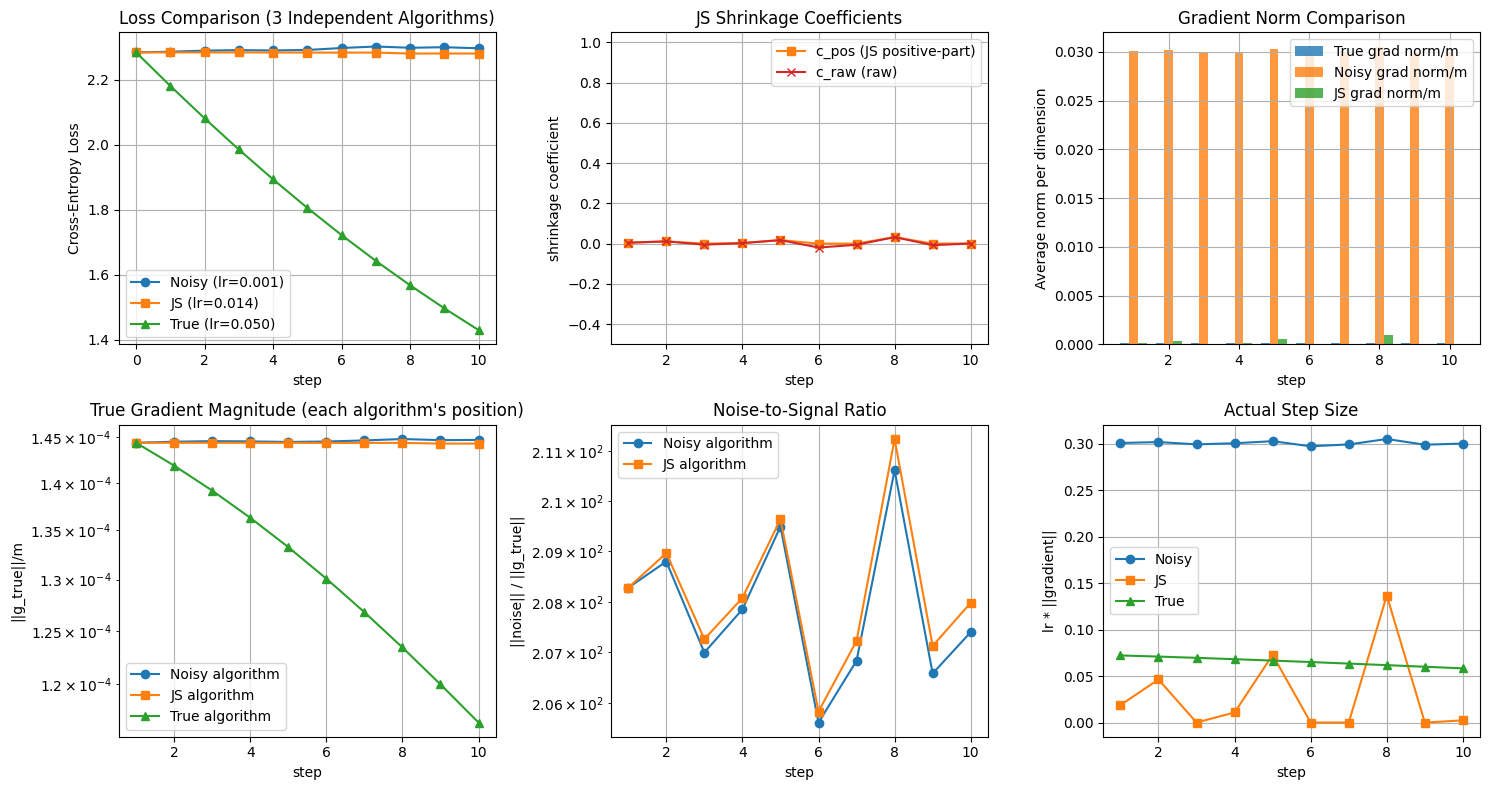


FINAL SUMMARY

Classification task:
  Input dimension: 1000
  Number of classes: 10
  Total parameters: 10000
  Number of samples: 500
  Noise level (sigma): 3.0

Final losses:
  Noisy Algorithm:  2.297625 (change: +0.012656)
  JS Algorithm:     2.281427 (change: -0.003542)
  True Algorithm:   1.430623 (change: -0.854345)

Optimal loss (at theta): 2.266991

Done.


In [71]:
import numpy as np
import matplotlib.pyplot as plt

def james_stein_positive(vec, sigma2):
    m = vec.size
    norm2 = np.sum(vec**2)
    if norm2 == 0:
        c_raw = -np.inf
    else:
        c_raw = 1.0 - (m - 2) * sigma2 / norm2
    c_pos = max(c_raw, 0.0)
    return c_pos * vec, c_pos, c_raw

def softmax(logits):
    """Numerically stable softmax"""
    logits_max = np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits - logits_max)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(W_flat, X_data, y_data, input_dim, n_classes):
    """Cross-entropy loss for multi-class classification"""
    W = W_flat.reshape(input_dim, n_classes)
    logits = X_data @ W  # (n_samples, n_classes)
    
    # Numerically stable cross-entropy using logsumexp
    logits_max = np.max(logits, axis=1, keepdims=True)
    log_sum_exp = np.log(np.sum(np.exp(logits - logits_max), axis=1)) + logits_max.squeeze()
    
    # Extract logits for true classes
    logits_true = logits[np.arange(len(y_data)), y_data]
    
    # Cross-entropy: -mean(log(p_true)) = mean(log_sum_exp - logit_true)
    loss = np.mean(log_sum_exp - logits_true)
    return loss

def cross_entropy_grad(W_flat, X_data, y_data, input_dim, n_classes):
    """Gradient of cross-entropy loss w.r.t. W"""
    n_samples = len(y_data)
    W = W_flat.reshape(input_dim, n_classes)
    logits = X_data @ W  # (n_samples, n_classes)
    
    # Compute softmax probabilities
    probs = softmax(logits)  # (n_samples, n_classes)
    
    # Subtract 1 from true class probabilities
    probs[np.arange(n_samples), y_data] -= 1
    
    # Gradient: X.T @ (probs - one_hot(y)) / n_samples
    grad_W = X_data.T @ probs / n_samples  # (input_dim, n_classes)
    
    return grad_W.flatten()

# ==================== Three Independent Algorithms ====================

def run_noisy_algorithm(x_init, sigma, lr, steps, rng, X_data, y_data, input_dim, n_classes, verbose=False):
    """
    Algorithm 1: Noisy Gradient Descent (baseline)
    Uses noisy gradients directly without any processing
    """
    m = x_init.size
    x = x_init.copy()
    sigma2 = sigma**2
    
    losses = [cross_entropy_loss(x, X_data, y_data, input_dim, n_classes)]
    norm_grad_list = []
    norm_noise_list = []
    norm_true_grad_list = []
    
    if verbose:
        print(f"\n  [Noisy Algorithm Diagnostics]")
        print(f"  Initial loss: {losses[0]:.6f}")
    
    for t in range(steps):
        # Compute true gradient at current position
        g_true = cross_entropy_grad(x, X_data, y_data, input_dim, n_classes)
        
        # Add noise
        noise = rng.normal(0.0, sigma, size=m)
        G = g_true + noise
        
        # Diagnostics
        norm_true = np.linalg.norm(g_true) / m
        norm_n = np.linalg.norm(noise) / m
        norm_G = np.linalg.norm(G) / m
        
        if verbose and t < 3:  # Print first 3 steps
            print(f"  Step {t+1}: ||g_true||/m={norm_true:.6f}, ||noise||/m={norm_n:.6f}, ||G||/m={norm_G:.6f}, lr*||G||={lr*norm_G*m:.6f}")
        
        # Update with noisy gradient
        x = x - lr * G
        
        losses.append(cross_entropy_loss(x, X_data, y_data, input_dim, n_classes))
        norm_grad_list.append(norm_G)
        norm_noise_list.append(norm_n)
        norm_true_grad_list.append(norm_true)
    
    if verbose:
        print(f"  Final loss: {losses[-1]:.6f} (change: {losses[-1]-losses[0]:+.6f})")
    
    return {
        'losses': np.array(losses),
        'norm_grad': np.array(norm_grad_list),
        'norm_noise': np.array(norm_noise_list),
        'norm_true_grad': np.array(norm_true_grad_list),
        'final_x': x
    }

def run_js_algorithm(x_init, sigma, lr, steps, rng, X_data, y_data, input_dim, n_classes, verbose=False):
    """
    Algorithm 2: James-Stein Denoised Gradient Descent
    Applies JS shrinkage to noisy gradients before update
    """
    m = x_init.size
    x = x_init.copy()
    sigma2 = sigma**2
    
    losses = [cross_entropy_loss(x, X_data, y_data, input_dim, n_classes)]
    norm_grad_list = []
    norm_noise_list = []
    norm_true_grad_list = []
    c_pos_list = []
    c_raw_list = []
    
    if verbose:
        print(f"\n  [JS Algorithm Diagnostics]")
        print(f"  Initial loss: {losses[0]:.6f}")
    
    for t in range(steps):
        # Compute true gradient at current position
        g_true = cross_entropy_grad(x, X_data, y_data, input_dim, n_classes)
        
        # Add noise
        noise = rng.normal(0.0, sigma, size=m)
        G = g_true + noise
        
        # Apply James-Stein shrinkage
        JS_est, c_pos, c_raw = james_stein_positive(G, sigma2)
        
        # Diagnostics
        norm_true = np.linalg.norm(g_true) / m
        norm_n = np.linalg.norm(noise) / m
        norm_G = np.linalg.norm(G) / m
        norm_JS = np.linalg.norm(JS_est) / m
        
        if verbose and t < 3:
            print(f"  Step {t+1}: ||g_true||/m={norm_true:.6f}, ||G||/m={norm_G:.6f}, c_pos={c_pos:.4f}, ||JS||/m={norm_JS:.6f}, lr*||JS||={lr*norm_JS*m:.6f}")
        
        # Update with JS denoised gradient
        x = x - lr * JS_est
        
        losses.append(cross_entropy_loss(x, X_data, y_data, input_dim, n_classes))
        norm_grad_list.append(norm_JS)
        norm_noise_list.append(norm_n)
        norm_true_grad_list.append(norm_true)
        c_pos_list.append(c_pos)
        c_raw_list.append(c_raw)
    
    if verbose:
        print(f"  Final loss: {losses[-1]:.6f} (change: {losses[-1]-losses[0]:+.6f})")
    
    return {
        'losses': np.array(losses),
        'norm_grad': np.array(norm_grad_list),
        'norm_noise': np.array(norm_noise_list),
        'norm_true_grad': np.array(norm_true_grad_list),
        'c_pos': np.array(c_pos_list),
        'c_raw': np.array(c_raw_list),
        'final_x': x
    }

def run_true_algorithm(x_init, lr, steps, X_data, y_data, input_dim, n_classes, verbose=False):
    """
    Algorithm 3: True Gradient Descent (oracle baseline)
    Uses true gradients without noise
    """
    m = x_init.size
    x = x_init.copy()
    
    losses = [cross_entropy_loss(x, X_data, y_data, input_dim, n_classes)]
    norm_grad_list = []
    
    if verbose:
        print(f"\n  [True Algorithm Diagnostics]")
        print(f"  Initial loss: {losses[0]:.6f}")
    
    for t in range(steps):
        # Compute true gradient at current position
        g_true = cross_entropy_grad(x, X_data, y_data, input_dim, n_classes)
        
        # Diagnostics
        norm_true = np.linalg.norm(g_true) / m
        
        if verbose and t < 3:
            print(f"  Step {t+1}: ||g_true||/m={norm_true:.6f}, lr*||g_true||={lr*norm_true*m:.6f}")
        
        # Update with true gradient
        x = x - lr * g_true
        
        losses.append(cross_entropy_loss(x, X_data, y_data, input_dim, n_classes))
        norm_grad_list.append(norm_true)
    
    if verbose:
        print(f"  Final loss: {losses[-1]:.6f} (change: {losses[-1]-losses[0]:+.6f})")
    
    return {
        'losses': np.array(losses),
        'norm_grad': np.array(norm_grad_list),
        'final_x': x
    }

# ==================== Three Independent Tuning Functions ====================

def tune_lr_noisy(input_dim=1000, n_classes=10, sigma=3.0, steps=10, 
                  seeds=(1,2,3,4,5), lr_grid=None, n_samples=500):
    """Tune learning rate for noisy gradient algorithm"""
    if lr_grid is None:
        lr_grid = np.linspace(0.001, 0.05, 100)
    
    best = None
    
    for lr in lr_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            m = input_dim * n_classes
            
            # Generate data
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            X_data = rng.randn(n_samples, input_dim)
            W_theta = theta.reshape(input_dim, n_classes)
            logits_theta = X_data @ W_theta
            y_data = np.argmax(logits_theta, axis=1)
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            
            # Run algorithm
            result = run_noisy_algorithm(x_init, sigma, lr, steps, rng, X_data, y_data, input_dim, n_classes)
            final_losses.append(result['losses'][-1])
        
        avg_final_loss = float(np.mean(final_losses))
        if (best is None) or (avg_final_loss < best[1]):
            best = (lr, avg_final_loss)
    
    return best

def tune_lr_js(input_dim=1000, n_classes=10, sigma=3.0, steps=10,
               seeds=(1,2,3,4,5), lr_grid=None, n_samples=500):
    """Tune learning rate for JS algorithm"""
    if lr_grid is None:
        lr_grid = np.linspace(0.001, 0.05, 100)
    
    best = None
    
    for lr in lr_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            m = input_dim * n_classes
            
            # Generate data
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            X_data = rng.randn(n_samples, input_dim)
            W_theta = theta.reshape(input_dim, n_classes)
            logits_theta = X_data @ W_theta
            y_data = np.argmax(logits_theta, axis=1)
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            
            # Run algorithm
            result = run_js_algorithm(x_init, sigma, lr, steps, rng, X_data, y_data, input_dim, n_classes)
            final_losses.append(result['losses'][-1])
        
        avg_final_loss = float(np.mean(final_losses))
        if (best is None) or (avg_final_loss < best[1]):
            best = (lr, avg_final_loss)
    
    return best

def tune_lr_true(input_dim=1000, n_classes=10, steps=10,
                 seeds=(1,2,3,4,5), lr_grid=None, n_samples=500):
    """Tune learning rate for true gradient algorithm"""
    if lr_grid is None:
        lr_grid = np.linspace(0.001, 0.05, 100)
    
    best = None
    
    for lr in lr_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            m = input_dim * n_classes
            
            # Generate data
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            X_data = rng.randn(n_samples, input_dim)
            W_theta = theta.reshape(input_dim, n_classes)
            logits_theta = X_data @ W_theta
            y_data = np.argmax(logits_theta, axis=1)
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            
            # Run algorithm
            result = run_true_algorithm(x_init, lr, steps, X_data, y_data, input_dim, n_classes)
            final_losses.append(result['losses'][-1])
        
        avg_final_loss = float(np.mean(final_losses))
        if (best is None) or (avg_final_loss < best[1]):
            best = (lr, avg_final_loss)
    
    return best

# ==================== Main Execution ====================

if __name__ == "__main__":
    # -------------------- user-tunable parameters --------------------
    input_dim = 1000
    n_classes = 10
    m = input_dim * n_classes  # 10000
    n_samples = 500
    sigma = 3.0
    steps = 10
    seeds = (999,)   # single seed for tuning
    
    # lr grids
    lr_noisy_grid = np.linspace(0.001, 0.05, 20)
    lr_js_grid = np.linspace(0.001, 0.05, 20)
    lr_true_grid = np.linspace(0.001, 0.05, 20)
    # ----------------------------------------------------------------

    print("\n" + "="*70)
    print("DIAGNOSTIC MODE: ANALYZING GRADIENT MAGNITUDES AND NOISE")
    print("="*70)
    
    # Generate shared dataset for diagnostics
    seed_diag = 999
    rng_diag = np.random.RandomState(seed_diag)
    theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
    X_data = rng_diag.randn(n_samples, input_dim)
    W_theta = theta.reshape(input_dim, n_classes)
    logits_theta = X_data @ W_theta
    y_data = np.argmax(logits_theta, axis=1)
    x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
    
    print(f"\nInitial Setup:")
    print(f"  m = {m}, sigma = {sigma}, n_samples = {n_samples}")
    print(f"  ||x_init|| = {np.linalg.norm(x_init):.2f}")
    print(f"  ||theta|| = {np.linalg.norm(theta):.2f}")
    print(f"  ||x_init - theta|| = {np.linalg.norm(x_init - theta):.2f}")
    
    # Initial gradient at x_init
    g_init = cross_entropy_grad(x_init, X_data, y_data, input_dim, n_classes)
    print(f"\nInitial gradient at x_init:")
    print(f"  ||g_init|| = {np.linalg.norm(g_init):.4f}")
    print(f"  ||g_init||/m = {np.linalg.norm(g_init)/m:.6f}")
    
    # Sample noise
    rng_noise = np.random.RandomState(seed_diag + 100)
    noise_sample = rng_noise.normal(0.0, sigma, size=m)
    print(f"\nNoise characteristics:")
    print(f"  ||noise|| = {np.linalg.norm(noise_sample):.4f}")
    print(f"  ||noise||/m = {np.linalg.norm(noise_sample)/m:.6f}")
    print(f"  Noise-to-signal ratio: ||noise||/||g_init|| = {np.linalg.norm(noise_sample)/np.linalg.norm(g_init):.2f}")
    
    loss_init = cross_entropy_loss(x_init, X_data, y_data, input_dim, n_classes)
    loss_theta = cross_entropy_loss(theta, X_data, y_data, input_dim, n_classes)
    print(f"\nLoss values:")
    print(f"  Loss at x_init: {loss_init:.6f}")
    print(f"  Loss at theta (optimal): {loss_theta:.6f}")

    print("\n" + "="*70)
    print("TUNING LEARNING RATES FOR THREE INDEPENDENT ALGORITHMS")
    print("="*70)
    
    # Tune each algorithm independently
    print("\n[1/3] Tuning Noisy Gradient Algorithm...")
    best_lr_noisy, best_avg_noisy_loss = tune_lr_noisy(
        input_dim=input_dim, n_classes=n_classes, sigma=sigma, steps=steps,
        seeds=seeds, lr_grid=lr_noisy_grid, n_samples=n_samples
    )
    print(f"  Best lr_noisy = {best_lr_noisy:.4f}, avg_final_loss = {best_avg_noisy_loss:.6f}")
    
    print("\n[2/3] Tuning James-Stein Algorithm...")
    best_lr_js, best_avg_js_loss = tune_lr_js(
        input_dim=input_dim, n_classes=n_classes, sigma=sigma, steps=steps,
        seeds=seeds, lr_grid=lr_js_grid, n_samples=n_samples
    )
    print(f"  Best lr_js = {best_lr_js:.4f}, avg_final_loss = {best_avg_js_loss:.6f}")
    
    print("\n[3/3] Tuning True Gradient Algorithm...")
    best_lr_true, best_avg_true_loss = tune_lr_true(
        input_dim=input_dim, n_classes=n_classes, steps=steps,
        seeds=seeds, lr_grid=lr_true_grid, n_samples=n_samples
    )
    print(f"  Best lr_true = {best_lr_true:.4f}, avg_final_loss = {best_avg_true_loss:.6f}")

    print("\n" + "="*70)
    print("RUNNING THREE INDEPENDENT EXPERIMENTS WITH BEST LRs")
    print("="*70)
    
    # Create independent RNG for each algorithm (same seed for fair noise comparison)
    rng_noisy = np.random.RandomState(seed_diag + 100)
    rng_js = np.random.RandomState(seed_diag + 100)  # Same seed as noisy
    
    # Run three independent algorithms with diagnostics
    print("\n[1/3] Running Noisy Gradient Algorithm...")
    result_noisy = run_noisy_algorithm(x_init, sigma, best_lr_noisy, steps, rng_noisy, 
                                       X_data, y_data, input_dim, n_classes, verbose=True)
    
    print("\n[2/3] Running James-Stein Algorithm...")
    result_js = run_js_algorithm(x_init, sigma, best_lr_js, steps, rng_js,
                                 X_data, y_data, input_dim, n_classes, verbose=True)
    
    print("\n[3/3] Running True Gradient Algorithm...")
    result_true = run_true_algorithm(x_init, best_lr_true, steps,
                                     X_data, y_data, input_dim, n_classes, verbose=True)

    # ==================== Visualization ====================
    
    print("\n" + "="*70)
    print("GENERATING COMPARISON PLOTS")
    print("="*70)
    
    steps_range = np.arange(0, steps+1)
    steps_bar = np.arange(1, steps+1)
    
    plt.figure(figsize=(15,8))
    
    # Plot 1: Loss comparison
    plt.subplot(2,3,1)
    plt.plot(steps_range, result_noisy['losses'], marker='o', label=f'Noisy (lr={best_lr_noisy:.3f})')
    plt.plot(steps_range, result_js['losses'], marker='s', label=f'JS (lr={best_lr_js:.3f})')
    plt.plot(steps_range, result_true['losses'], marker='^', label=f'True (lr={best_lr_true:.3f})')
    plt.xlabel("step")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Loss Comparison (3 Independent Algorithms)")
    plt.legend()
    plt.grid(True)
    
    # Plot 2: JS shrinkage coefficients
    plt.subplot(2,3,2)
    plt.plot(steps_bar, result_js['c_pos'], marker='s', label='c_pos (JS positive-part)', color='C1')
    plt.plot(steps_bar, result_js['c_raw'], marker='x', label='c_raw (raw)', color='C3')
    plt.xlabel("step")
    plt.ylabel("shrinkage coefficient")
    plt.title("JS Shrinkage Coefficients")
    plt.ylim(-0.5, 1.05)
    plt.legend()
    plt.grid(True)
    
    # Plot 3: Gradient norms
    plt.subplot(2,3,3)
    width = 0.25
    plt.bar(steps_bar - width, result_true['norm_grad'], width, label='True grad norm/m', alpha=0.8)
    plt.bar(steps_bar, result_noisy['norm_grad'], width, label='Noisy grad norm/m', alpha=0.8)
    plt.bar(steps_bar + width, result_js['norm_grad'], width, label='JS grad norm/m', alpha=0.8)
    plt.xlabel("step")
    plt.ylabel("Average norm per dimension")
    plt.title("Gradient Norm Comparison")
    plt.legend()
    plt.grid(True)
    
    # Plot 4: True gradient norms over steps
    plt.subplot(2,3,4)
    plt.plot(steps_bar, result_noisy['norm_true_grad'], marker='o', label='Noisy algorithm')
    plt.plot(steps_bar, result_js['norm_true_grad'], marker='s', label='JS algorithm')
    plt.plot(steps_bar, result_true['norm_grad'], marker='^', label='True algorithm')
    plt.xlabel("step")
    plt.ylabel("||g_true||/m")
    plt.title("True Gradient Magnitude (each algorithm's position)")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    
    # Plot 5: Noise-to-signal ratio
    plt.subplot(2,3,5)
    nsr_noisy = result_noisy['norm_noise'] / result_noisy['norm_true_grad']
    nsr_js = result_js['norm_noise'] / result_js['norm_true_grad']
    plt.plot(steps_bar, nsr_noisy, marker='o', label='Noisy algorithm')
    plt.plot(steps_bar, nsr_js, marker='s', label='JS algorithm')
    plt.xlabel("step")
    plt.ylabel("||noise|| / ||g_true||")
    plt.title("Noise-to-Signal Ratio")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    
    # Plot 6: Step sizes
    plt.subplot(2,3,6)
    step_size_noisy = best_lr_noisy * result_noisy['norm_grad'] * m
    step_size_js = best_lr_js * result_js['norm_grad'] * m
    step_size_true = best_lr_true * result_true['norm_grad'] * m
    plt.plot(steps_bar, step_size_noisy, marker='o', label='Noisy')
    plt.plot(steps_bar, step_size_js, marker='s', label='JS')
    plt.plot(steps_bar, step_size_true, marker='^', label='True')
    plt.xlabel("step")
    plt.ylabel("lr * ||gradient||")
    plt.title("Actual Step Size")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # ==================== Summary ====================
    
    print("\n" + "="*70)
    print("FINAL SUMMARY")
    print("="*70)
    
    print(f"\nClassification task:")
    print(f"  Input dimension: {input_dim}")
    print(f"  Number of classes: {n_classes}")
    print(f"  Total parameters: {m}")
    print(f"  Number of samples: {n_samples}")
    print(f"  Noise level (sigma): {sigma}")
    
    print(f"\nFinal losses:")
    print(f"  Noisy Algorithm:  {result_noisy['losses'][-1]:.6f} (change: {result_noisy['losses'][-1]-result_noisy['losses'][0]:+.6f})")
    print(f"  JS Algorithm:     {result_js['losses'][-1]:.6f} (change: {result_js['losses'][-1]-result_js['losses'][0]:+.6f})")
    print(f"  True Algorithm:   {result_true['losses'][-1]:.6f} (change: {result_true['losses'][-1]-result_true['losses'][0]:+.6f})")
    
    print(f"\nOptimal loss (at theta): {loss_theta:.6f}")
    
    print("\nDone.")
